In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
import kagglehub
import shutil
import os

path = kagglehub.dataset_download("suraj520/customer-support-ticket-dataset")

os.makedirs("../data", exist_ok=True)

shutil.copy(
    os.path.join(path, "customer_support_tickets.csv"),
    "../data/customer_support_tickets.csv"
)

'../data/customer_support_tickets.csv'

In [38]:
df = pd.read_csv("../data/customer_support_tickets.csv")

df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [39]:
df.shape

(8469, 17)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [41]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Ticket ID,8469.0,NaN,NaN,NaN,4235.0,2444.934048,1.0,2118.0,4235.0,6352.0,8469.0
Customer Name,8469,8028,Michael Garcia,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Email,8469,8320,bsmith@example.com,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Age,8469.0,NaN,NaN,NaN,44.026804,15.296112,18.0,31.0,44.0,57.0,70.0
Customer Gender,8469,3,Male,2896,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product Purchased,8469,42,Canon EOS,240,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date of Purchase,8469,730,2020-10-21,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ticket Type,8469,5,Refund request,1752,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ticket Subject,8469,16,Refund request,576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ticket Description,8469,8077,I'm having an issue with the {product_purchase...,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
df.isnull().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

In [43]:
df.duplicated().sum()

0

In [44]:
df.nunique()

Ticket ID                       8469
Customer Name                   8028
Customer Email                  8320
Customer Age                      53
Customer Gender                    3
Product Purchased                 42
Date of Purchase                 730
Ticket Type                        5
Ticket Subject                    16
Ticket Description              8077
Ticket Status                      3
Resolution                      2769
Ticket Priority                    4
Ticket Channel                     4
First Response Time             5470
Time to Resolution              2728
Customer Satisfaction Rating       5
dtype: int64

In [45]:
df = df.drop_duplicates()

df["Date of Purchase"] = pd.to_datetime(
    df["Date of Purchase"], errors="coerce"
)

df["Customer Satisfaction Rating"] = pd.to_numeric(
    df["Customer Satisfaction Rating"], errors="coerce"
)

In [46]:
categorical_columns = [
    "Ticket Type",
    "Ticket Priority",
    "Ticket Channel",
    "Ticket Status"
]

for column in categorical_columns:
    print(column)
    print(df[column].value_counts())
    print()

Ticket Type
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

Ticket Priority
Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

Ticket Channel
Ticket Channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name: count, dtype: int64

Ticket Status
Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64



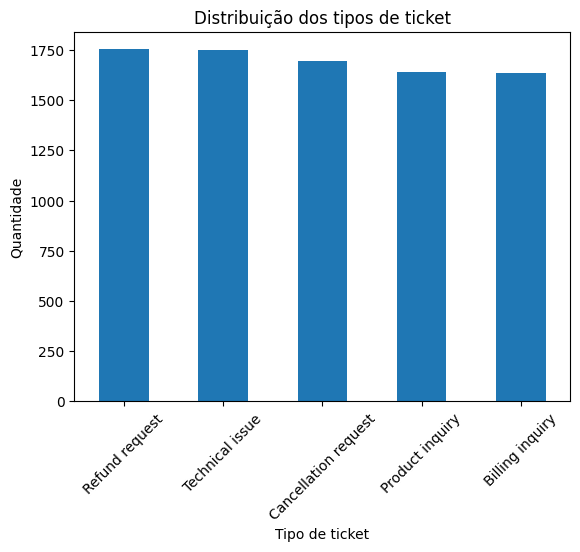

In [47]:
df["Ticket Type"].value_counts().plot(kind="bar")
plt.title("Distribuição dos tipos de ticket")
plt.xlabel("Tipo de ticket")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.show()

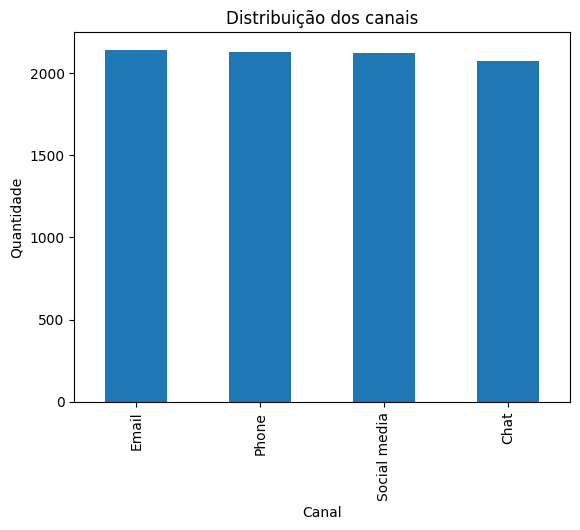

In [48]:
df["Ticket Channel"].value_counts().plot(kind="bar")
plt.title("Distribuição dos canais")
plt.xlabel("Canal")
plt.ylabel("Quantidade")
plt.show()

In [49]:
df["First Response Time"] = pd.to_timedelta(
    df["First Response Time"], errors="coerce"
).dt.total_seconds() / 3600

df["Time to Resolution"] = pd.to_timedelta(
    df["Time to Resolution"], errors="coerce"
).dt.total_seconds() / 3600

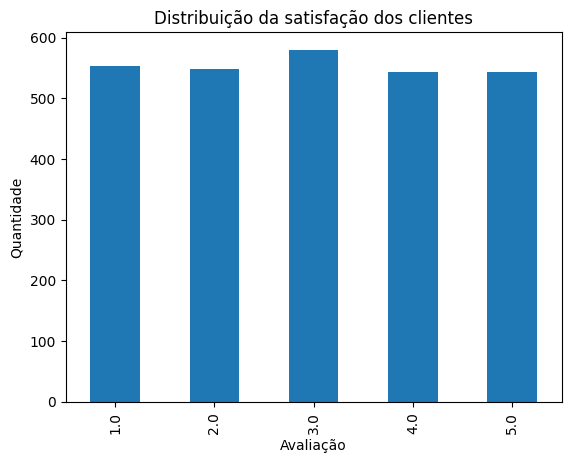

In [50]:
df["Customer Satisfaction Rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribuição da satisfação dos clientes")
plt.xlabel("Avaliação")
plt.ylabel("Quantidade")
plt.show()

## Hipóteses

1. Tickets de problemas técnicos podem mostrar uma das principais intenções dos usuários pela frequência.

2. Tickets de alta prioridade podem ser de problemas mais urgentes, como falhas de serviço, cobrança ou dificuldades de acesso.

3. Solicitações de reembolso, cancelamento e problemas de cobrança são de diferentes que podem ser identificadas futuramente pelo texto do ticket.

4. Tickets com maior tempo de resolução podem estar associados a problemas técnicos ou solicitações que precisam de muita investigação.